In [1]:
# Imports and Configurations
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical Testing
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

# NASDAQ Universe 
TICKERS = [
    'AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'ALGN', 'AMAT', 'AMD', 'AMGN',
    'AMZN', 'ANSS', 'ASML', 'AVGO', 'AZN', 'BIIB', 'BKNG', 'BKR', 'CCEP',
    'CDNS', 'CDW', 'COST', 'CPRT', 'CSGP', 'CSCO', 'CTAS', 'CTSH', 'DLTR',
    'DXCM', 'EA', 'EXC', 'FANG', 'FAST', 'FTNT', 'GILD', 'GOOG', 'GOOGL',
    'HON', 'IDXX', 'ILMN', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LIN', 'LRCX',
    'MAR', 'MCHP', 'MDLZ', 'MELI', 'META', 'MNST', 'MRNA', 'MRVL', 'MSFT',
    'MTCH', 'MU', 'NFLX', 'NVDA', 'ODFL', 'ON', 'ORLY', 'PANW', 'PARA',
    'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SIRI', 'SMCI',
    'SNPS', 'TXN', 'VRSK', 'VRTX', 'WBD', 'WDAY', 'XEL'
]

# Defining Periods (matching Notebook 4)
TRAIN_START = '2014-01-01'
TRAIN_END   = '2017-12-31'
VAL_START   = '2018-01-01'
VAL_END     = '2020-12-31'
TEST_START  = '2021-01-01'
TEST_END    = '2023-12-31'

# Strategy Parameters (matching Notebook 3 and 4)
SHARPE_WINDOW    = 52
ZSCORE_WINDOW    = 52
ENTRY_THRESHOLD  = 2.0
EXIT_THRESHOLD   = 0.5
STOP_LOSS        = 3.5
HIGH_VOL_ENTRY   = 2.5
LOW_VOL_ENTRY    = 1.5
VOL_WINDOW       = 26
VOL_THRESHOLD    = 1.5

# Clustering parameters (same as Notebook 2)
K_VALUES = [2,4,7]

print('Notebook 5: OCP Clustering for Pairs Trading')
print('=' * 55)
print(f'Universe:          {len(TICKERS)} stocks')
print(f'K Values:          {K_VALUES}')
print(f'Sharpe window:     {SHARPE_WINDOW} weeks')
print(f'Training period:   {TRAIN_START} to {TRAIN_END}')
print(f'Validation period: {VAL_START} to {VAL_END}')
print(f'Test period:    {TEST_START} to {TEST_END}')
print('\nAll imports successful.')

Notebook 5: OCP Clustering for Pairs Trading
Universe:          79 stocks
K Values:          [2, 4, 7]
Sharpe window:     52 weeks
Training period:   2014-01-01 to 2017-12-31
Validation period: 2018-01-01 to 2020-12-31
Test period:    2021-01-01 to 2023-12-31

All imports successful.


In [2]:
# Downloading price data
import yfinance as yf

print('Downloading price data for NASDAQ 100 universe...')
print(f'Tickers: {len(TICKERS)} stocks, 2014-2023, weekly Wednesday\n')

raw = yf.download(
    TICKERS, 
    start='2014-01-01',
    end='2024-01-01',
    interval='1wk',
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')
price_data = price_data.ffill().dropna(axis=1)

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers retained: {len(price_data.columns)}')

# Computing weekly returns
returns = price_data.pct_change().dropna()

print(f'\nReturns shape: {returns.shape}')

# Computing rolling Sharpe Ratio
print(f'\nComputing rolling {SHARPE_WINDOW}-week Sharpe Ratio...')

def compute_sharpe(returns, window=52):
    """
    Computes rolling annualized Sharpe Ratio for each stock.
    Sharpe = (mean return / std return) * sqrt(52)
    No risk-free rate subtracted - consistent with Notebook 2.
    """
    rolling_mean = returns.rolling(window=window).mean()
    rolling_std  = returns.rolling(window=window).std()
    sharpe       = (rolling_mean / rolling_std) * np.sqrt(52)
    return sharpe

sharpe_data = compute_sharpe(returns, window=SHARPE_WINDOW)
sharpe_data = sharpe_data.dropna(how='all')

# Retaining tickers only present in both price and sharpe data
common_tickers = [t for t in price_data.columns
                  if t in sharpe_data.columns]
price_data     = price_data[common_tickers]
sharpe_data    = sharpe_data[common_tickers]

print(f'Sharpe data shape: {sharpe_data.shape}')
print(f'Date range: {sharpe_data.index[0].date()} to '
      f'{sharpe_data.index[-1].date()}')
print(f'Tickers retained: {len(common_tickers)}')
print(f'\nTicker list: {','.join(common_tickers)}')

Tickers: 79 stocks, 2014-2023, weekly Wednesday



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ANSS: possibly delisted; no timezone found      ]  68 of 79 completed
[**********************92%*******************    ]  73 of 79 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
$PARA: possibly delisted; no timezone found****  ]  76 of 79 completed
[*********************100%***********************]  79 of 79 completed

2 Failed downloads:
['ANSS', 'PARA']: possibly delisted; no timezone found



Price data shape: (522, 76)
Date range: 2014-01-01 to 2023-12-27
Tickers retained: 76

Returns shape: (521, 76)

Computing rolling 52-week Sharpe Ratio...
Sharpe data shape: (470, 76)
Date range: 2014-12-31 to 2023-12-27
Tickers retained: 76

Ticker list: AAPL,ADBE,ADI,ADP,ADSK,ALGN,AMAT,AMD,AMGN,AMZN,ASML,AVGO,AZN,BIIB,BKNG,BKR,CCEP,CDNS,CDW,COST,CPRT,CSCO,CSGP,CTAS,CTSH,DLTR,DXCM,EA,EXC,FANG,FAST,FTNT,GILD,GOOG,GOOGL,HON,IDXX,ILMN,INTU,ISRG,KDP,KLAC,LIN,LRCX,MAR,MCHP,MDLZ,MELI,META,MNST,MRVL,MSFT,MTCH,MU,NFLX,NVDA,ODFL,ON,ORLY,PANW,PAYX,PCAR,PEP,QCOM,REGN,ROST,SBUX,SIRI,SMCI,SNPS,TXN,VRSK,VRTX,WBD,WDAY,XEL


In [3]:
# Optimal Causal Path (OCP) Distance Function
def ocp_distance(x,y):
    """
    Computes the Optimal Causal Path (OCP) distance between two time series.

    Based on Stubinger (2019): "Statistical Arbitrage with Optimal Causal Paths
    on High-Frequency Data of the S&P500."

    The key difference from standard DTW:
    - DTW allows warping in both directions (symmetric)
    - OCP enforces causality - the warping path can only move forward in time
      meaning series x at time t can only be matched to sereies y at time t
      or later, never to time t-1 or earlier.

    This prevents economically meaningless backward-looking matches and ensures
    only genuinely exploitable lead-lag relationships are captured.

    Parameters:
        x: numpy arrays - first time series (e.g. Sharpe ratio series of stock A)
        y: numpy arrays - second time series (e.g. Sharpe ratio series of stock B)

    Returns:
        float: OCP distance between x and y. Lower = more causally similar.
    """
    n = len(x)
    m = len(y)

    # Initializing cost matrix
    D = np.full((n, m), np.inf)

    # Starting point
    D[0,0] = (x[0] - y[0]) ** 2

    # Filling first column: x can only match y[0] moving forward
    # for i in range(1,n):
        # D[i,0] = D[i-1,0] + (x[i] - y[0]) ** 2

    # Filling first row: y can only match x[0] moving forward
    for j in range(1,m):
        D[0,j] = D[0,j-1] + (x[0] - y[j]) ** 2

    # Fill remaining cells with causality constraints
    for i in range(1,n):
        for j in range(1,m):
            # This prevents y at time j from being matched to x at time i
            if j >= i:
                cost   = (x[i] - y[j]) ** 2
                D[i,j] = cost + min(
                    D[i-1, j],
                    D[i, j-1],
                    D[i-1, j-1]
                )

    # Returning normalized distance
    return np.sqrt(D[n-1, m-1]) / (n + m)   

# Verifying OCP function with a simple test
print("Testing OCP distance function...")

# Two identical time series should have distance 0
x_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
d_identical = ocp_distance(x_test, y_test)
print(f'Distance between identical series: {d_identical:.6f} (should be 0.0)')

# Two different series should have positive distance
y_test2 = np.array([5.0, 4.0, 3.0, 2.0, 1.0])
d_different = ocp_distance(x_test, y_test2)
print(f'Distance between opposite series: {d_different:.6f} (should be > 0)')

# OCP should be asymmetric - ocp(x,y) may not be equal to ocp(y,x)
x_lead = np.array([1.0, 3.0, 2.0, 4.0, 3.0, 5.0, 4.0])
y_lag  = np.array([0.0, 0.0, 1.0, 3.0, 2.0, 4.0, 3.0])
d_forward  = ocp_distance(x_lead, y_lag)
d_backward = ocp_distance(y_lag, x_lead)
print(f"OCP(x_lead, y_lag):  {d_forward:.6f}")
print(f"OCP(y_lag, x_lead):  {d_backward:.6f}")
print(f"Asymmetric: {abs(d_forward - d_backward) > 1e-10}")
print(f"x leads y: {d_forward < d_backward}")

print('\nOCP distance function verified.')

Testing OCP distance function...
Distance between identical series: 0.000000 (should be 0.0)
Distance between opposite series: 0.632456 (should be > 0)
OCP(x_lead, y_lag):  0.159719
OCP(y_lag, x_lead):  0.276642
Asymmetric: True
x leads y: True

OCP distance function verified.


In [4]:
import time

def compute_ocp_matrix(sharpe_data):
    """
    Computes the pairwise OCP distance matrix for all stocks.

    For each pair (i,j) computes both ocp(i,j) and ocp(j,i) and
    takes the minimum as the symmetric distance for clustering.

    This improves on Stubinger (2019) who assumes a fixed lead-lag
    direction. Taking the minimum captures the strongest causal
    relationship regardless of direction.

    Returns a symmetric n x n distance matrix.
    """
    tickers = sharpe_data.columns.tolist()
    n       = len(tickers)
    matrix  = np.zeros((n, n))

    total_pairs = n * (n - 1) // 2
    completed   =  0
    
    print(f'Computing OCP distances for {n} stocks...')
    print(f'Total unique pairs: {total_pairs}')

    start_time = time.time()

    for i in range(n):
        for j in range(i + 1, n):
            x = sharpe_data.iloc[:, i].values
            y = sharpe_data.iloc[:, j].values

            # Removing any NaN values
            mask = ~(np.isnan(x) | np.isnan(y))
            x    = x[mask]
            y    = y[mask]

            # Computing OCP in both directions and take minimum 
            d_xy = ocp_distance(x, y)
            d_yx = ocp_distance(y, x)
            d    = min(d_xy, d_yx)

            # Filling both sides of symmetric matrix
            matrix[i, j] = d
            matrix[j, i] = d

            completed += 1
            if completed % 200 == 0 and completed > 0:
                elapsed = time.time() - start_time
                pct     = completed / total_pairs * 100
                eta     = (elapsed / completed) * (total_pairs - completed)
                print(f'  {completed}/{total_pairs} pairs '
                      f' ({pct:.1f}%) - '
                      f'elapsed: {elapsed:.0f}s - '
                      f'ETA: {eta:.0f}s')

    elapsed = time.time() - start_time
    print(f'\nComplete. Total time: {elapsed:.0f} seconds')
    print(f'Distance matrix shape: {matrix.shape}')

    return matrix, tickers   

# Running Computations
print('Starting OCP distance matrix computation...')
print('Note: OCP requires two passes per pair (both directions)')
print('Expected time: 20-60 minutes depending on your machine\n')

ocp_matrix, tickers = compute_ocp_matrix(sharpe_data)

# Saving immediately
np.save('ocp_distance_matrix.npy', ocp_matrix)
print(f'\nDistance matrix saved to ocp_distance_matrix.npy')
print('Do not close the notebook until this save is confirmed.')

# Basic Validation
print(f'\nMatrix Validation:')
print(f'  Shape:                  {ocp_matrix.shape}')
print(f'  Diagonal (should be 0): {np.diag(ocp_matrix).max():.6f}')
print(f'  Min off-diagonal:       {ocp_matrix[ocp_matrix > 0].min():.6f}')
print(f'  Max distance:           {ocp_matrix.max():.6f}')
print(f'  Symmetric:              {np.allclose(ocp_matrix, ocp_matrix.T)}')

Starting OCP distance matrix computation...
Note: OCP requires two passes per pair (both directions)
Expected time: 20-60 minutes depending on your machine

Computing OCP distances for 76 stocks...
Total unique pairs: 2850
  200/2850 pairs  (7.0%) - elapsed: 76s - ETA: 1010s
  400/2850 pairs  (14.0%) - elapsed: 149s - ETA: 911s
  600/2850 pairs  (21.1%) - elapsed: 224s - ETA: 842s
  800/2850 pairs  (28.1%) - elapsed: 309s - ETA: 793s
  1000/2850 pairs  (35.1%) - elapsed: 387s - ETA: 715s
  1200/2850 pairs  (42.1%) - elapsed: 464s - ETA: 637s
  1400/2850 pairs  (49.1%) - elapsed: 534s - ETA: 553s
  1600/2850 pairs  (56.1%) - elapsed: 606s - ETA: 474s
  1800/2850 pairs  (63.2%) - elapsed: 678s - ETA: 396s
  2000/2850 pairs  (70.2%) - elapsed: 758s - ETA: 322s
  2200/2850 pairs  (77.2%) - elapsed: 844s - ETA: 249s
  2400/2850 pairs  (84.2%) - elapsed: 921s - ETA: 173s


KeyboardInterrupt: 

In [ ]:
np.save('ocp_distance_matrix.npy', ocp_matrix)
pd.Series(tickers).to_csv('ocp_tickers.csv', index=False)
sharpe_data.to_csv('ocp_sharpe_data.csv')
print("Saved:")
print("  ocp_distance_matrix.npy")
print("  ocp_tickers.csv")
print("  ocp_sharpe_data.csv")

In [5]:
# Loading saved OCP data 
ocp_matrix  = np.load('ocp_distance_matrix.npy')
tickers     = pd.read_csv('ocp_tickers.csv').iloc[:, 0].tolist()
sharpe_data = pd.read_csv('ocp_sharpe_data.csv', 
                           index_col=0, parse_dates=True)
print(f"Loaded matrix:    {ocp_matrix.shape}")
print(f"Loaded tickers:   {len(tickers)} stocks")
print(f"Loaded Sharpe:    {sharpe_data.shape}")
print(f"First 5 tickers:  {tickers[:5]}")

Loaded matrix:    (76, 76)
Loaded tickers:   76 stocks
Loaded Sharpe:    (470, 76)
First 5 tickers:  ['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK']


Loaded OCP matrix shape: (76, 76)
OCP heirarchical clustering complete.
Linkage matrix shape: (75, 4)

k=2:
 Cluster 1 (27 stocks): ADI, AMD, AZN, BIIB, BKNG, BKR, CCEP, CTSH, FANG, FAST, GILD, ILMN, LIN, MCHP, MDLZ, MRVL, MTCH, MU, ON, PCAR, QCOM, REGN, SIRI, VRSK, VRTX, WBD, WDAY
 Cluster 2 (49 stocks): AAPL, ADBE, ADP, ADSK, ALGN, AMAT, AMGN, AMZN, ASML, AVGO, CDNS, CDW, COST, CPRT, CSCO, CSGP, CTAS, DLTR, DXCM, EA, EXC, FTNT, GOOG, GOOGL, HON, IDXX, INTU, ISRG, KDP, KLAC, LRCX, MAR, MELI, META, MNST, MSFT, NFLX, NVDA, ODFL, ORLY, PANW, PAYX, PEP, ROST, SBUX, SMCI, SNPS, TXN, XEL

k=4:
 Cluster 1 (5 stocks): BIIB, ILMN, MTCH, SIRI, WBD
 Cluster 2 (22 stocks): ADI, AMD, AZN, BKNG, BKR, CCEP, CTSH, FANG, FAST, GILD, LIN, MCHP, MDLZ, MRVL, MU, ON, PCAR, QCOM, REGN, VRSK, VRTX, WDAY
 Cluster 3 (18 stocks): ADP, ADSK, ALGN, AMGN, CSCO, CSGP, DLTR, DXCM, EA, EXC, HON, KDP, MNST, PEP, ROST, SBUX, TXN, XEL
 Cluster 4 (31 stocks): AAPL, ADBE, AMAT, AMZN, ASML, AVGO, CDNS, CDW, COST, CPRT, CT

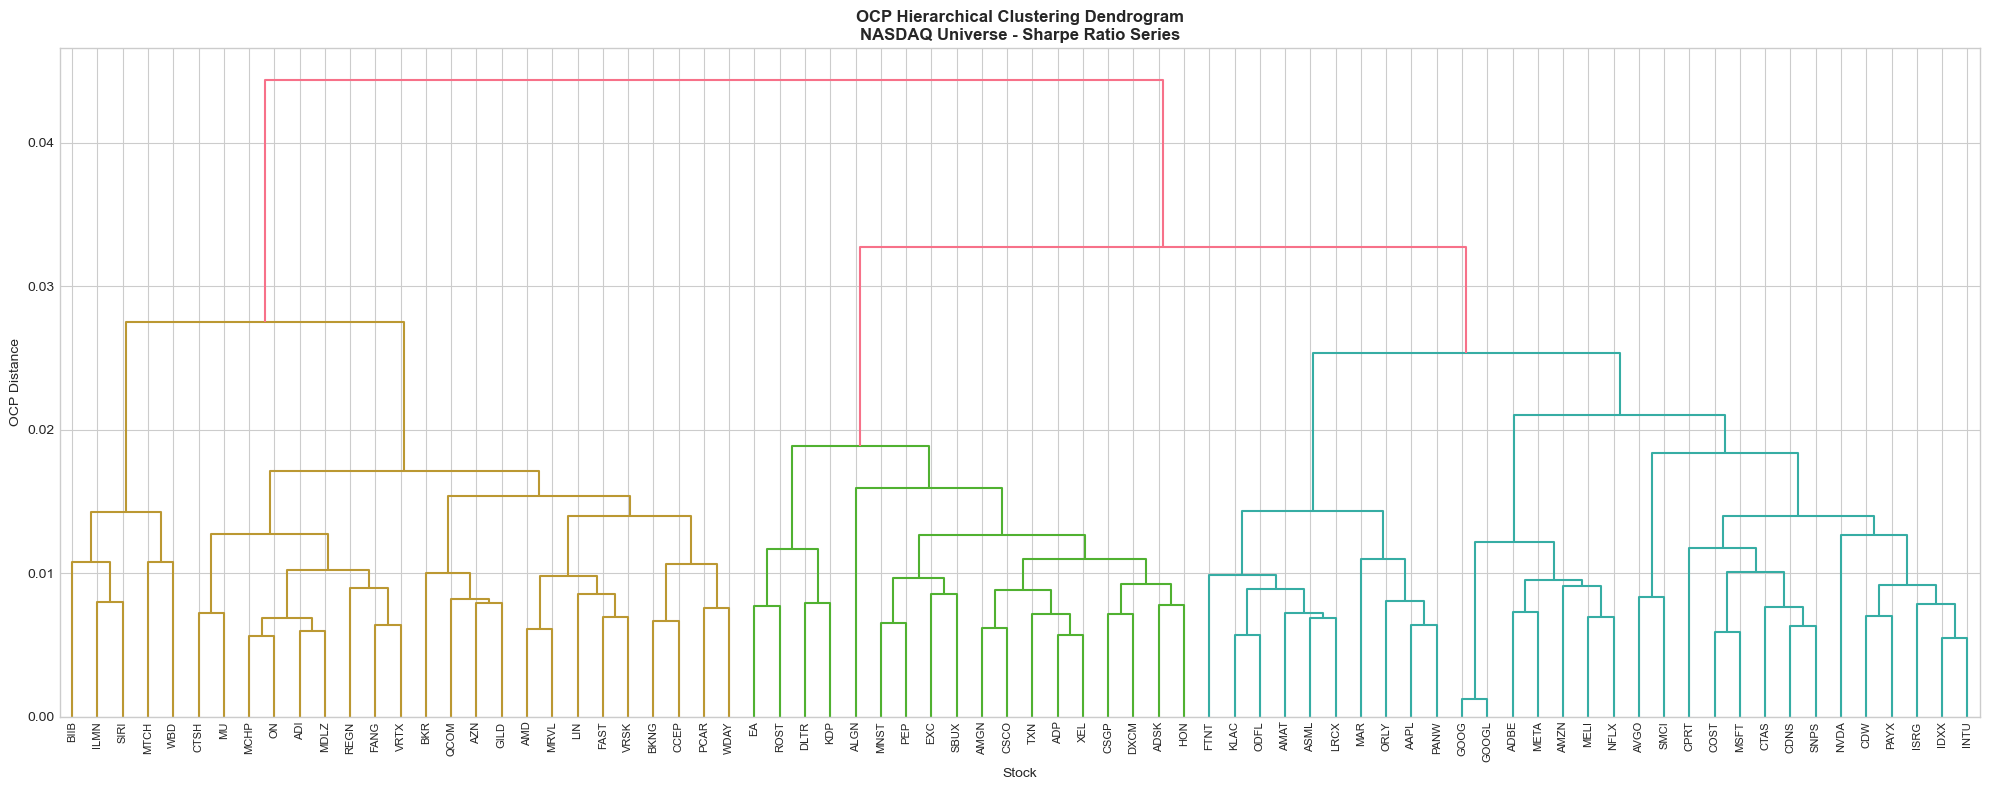


Cluster assignments saved for k=2, k=4, k=7.


In [6]:
ocp_matrix = np.load('ocp_distance_matrix.npy')
tickers = sharpe_data.columns.tolist()
print(f'Loaded OCP matrix shape: {ocp_matrix.shape}')

# Hierarchical clustering with OCP distance matrix

condensed_dist = squareform(ocp_matrix)

ocp_linkage = linkage(condensed_dist, method='ward')

print('OCP heirarchical clustering complete.')
print(f'Linkage matrix shape: {ocp_linkage.shape}')

# Generating cluster assignments for each k value
ocp_clusters = {}

for k in K_VALUES:
    cluster_labels = fcluster(ocp_linkage, k, criterion='maxclust')
    ocp_clusters[k] = pd.DataFrame({
        'Ticker': tickers,
        'Cluster': cluster_labels
    })

    print(f'\nk={k}:')
    for cluster_num in sorted(ocp_clusters[k]['Cluster'].unique()):
        cluster_tickers = ocp_clusters[k][
            ocp_clusters[k]['Cluster'] == cluster_num
        ]['Ticker'].tolist()
        print(f' Cluster {cluster_num} ({len(cluster_tickers)} stocks): '
              f'{', '.join(cluster_tickers)}')  

# Plotting Dendrogram
plt.figure(figsize=(20,8))
dendrogram(ocp_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=8)
plt.title('OCP Hierarchical Clustering Dendrogram\n'
          'NASDAQ Universe - Sharpe Ratio Series',
          fontweight='bold')
plt.xlabel('Stock')
plt.ylabel('OCP Distance')
plt.tight_layout()
plt.savefig('ocp_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving clustering assignments
for k in K_VALUES:
    ocp_clusters[k].to_csv(f'ocp_cluster_assignments_k{k}.csv',index=False)

print('\nCluster assignments saved for k=2, k=4, k=7.')

In [7]:
# Cluster validity indices for OCP Clustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print('Computing cluster validity indices for OCP clustering...')
print('(Silhouette, Calinski-Harabasz, Davies-Bouldin)\n')

ocp_cvi_results = []

for k in K_VALUES:
    cluster_labels = ocp_clusters[k]['Cluster'].values

    sil = silhouette_score(ocp_matrix, cluster_labels, metric='precomputed')
    ch  = calinski_harabasz_score(sharpe_data.T.values, cluster_labels)
    db  = davies_bouldin_score(sharpe_data.T.values, cluster_labels)

    ocp_cvi_results.append({
        'k': k,
        'Silhouette': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)
    })

ocp_cvi_df = pd.DataFrame(ocp_cvi_results).set_index('k')

print('OCP Cluster Validity Indices:')
print(ocp_cvi_df.to_string())
print("""
Interpretation guide:
    Silhouette:          higher is better (range -1 to 1)
    Calinski-Harabasz:   higher is better (no fixed range)
    Davies-Bouldin:      lower is better  (range 0 to infinity)
""")

# Compare cluster membership: OCP vs. DTW
# Loading DTW cluster assignments from Notebook 2 for comparison
print('Loading DTW cluster assignments from Notebook 2 for comparison...')

dtw_clusters = {}
for k in K_VALUES:
    try: 
        dtw_clusters[k] = pd.read_csv(f'cluster_assignments_sharpe_k{k}.csv')
        print(f' k={k}: loaded {len(dtw_clusters[k])} ticker assignments')
    except FileNotFoundError:
        print(f' k={k}: file not found, skipping comparison for k')

# Computing cluster agreement using Adjusted Random Index
from sklearn.metrics import adjusted_rand_score

print('\nComparing OCP and DTW cluster membership (Adjusted Rand Index):')
print('(0 = no agreement / random, 1 = perfect agreement)\n')

for k in K_VALUES:
    if k in dtw_clusters:
        # Aligning on common tickers
        merged = pd.merge(
            ocp_clusters[k], dtw_clusters[k],
            on='Ticker', suffixes=('_ocp', '_dtw')
        )

        ari = adjusted_rand_score(
            merged['Cluster_ocp'], merged['Cluster_dtw']
        )

        print(f' k={k}: ARI = {ari:.4f} '
              f'({len(merged)} common tickers)')       

Computing cluster validity indices for OCP clustering...
(Silhouette, Calinski-Harabasz, Davies-Bouldin)

OCP Cluster Validity Indices:
   Silhouette  Calinski-Harabasz  Davies-Bouldin
k                                               
2      0.1407             7.1900          3.0086
4      0.1153             5.1600          2.8279
7      0.1022             3.5000          3.1739

Interpretation guide:
    Silhouette:          higher is better (range -1 to 1)
    Calinski-Harabasz:   higher is better (no fixed range)
    Davies-Bouldin:      lower is better  (range 0 to infinity)

Loading DTW cluster assignments from Notebook 2 for comparison...
 k=2: file not found, skipping comparison for k
 k=4: file not found, skipping comparison for k
 k=7: file not found, skipping comparison for k

Comparing OCP and DTW cluster membership (Adjusted Rand Index):
(0 = no agreement / random, 1 = perfect agreement)



In [8]:
# Building cluster map from OCP assignments
ocp_cluster_map = {}

for k in K_VALUES:
    ocp_cluster_map[k] = {}
    for cluster_num in sorted(ocp_clusters[k]['Cluster'].unique()):
        tickers_in_cluster = ocp_clusters[k][
            ocp_clusters[k]['Cluster'] == cluster_num
        ]['Ticker'].tolist()
        ocp_cluster_map[k][cluster_num] = tickers_in_cluster

print("OCP cluster map built.")
print(f'k values: {list(ocp_cluster_map.keys())}')

# Defining Cointegration test function
def test_cointegration(s1, s2, ticker1, ticker2):
    combined = pd.concat([s1,s2], axis=1).dropna()
    s1_clean = combined.iloc[:,0]
    s2_clean = combined.iloc[:,1]

    score, pvalue, _ = coint(s1_clean, s2_clean)
    pvalue = float(pvalue)
    score  = float(score)

    pvalue_rounded = round(pvalue, 4)
    score_rounded  = round(score,  4)

    return {
        'Ticker 1':     ticker1,
        'Ticker 2':     ticker2,
        'Score':        score_rounded,
        'p-value':      pvalue_rounded,
        'Cointegrated': 'Yes' if pvalue_rounded < 0.05 else 'No'
    }
# Running cointegration tests across all k values and clusters
print('\nRunning Engle-Granger cointegration tests...')
print('Using full price history (2014-2023) on OCP clusters.\n')

ocp_coint_results = {}

for k in K_VALUES:
    ocp_coint_results[k] = {}
    total_pairs          = 0
    total_cointegrated   = 0

    print(f'\n{'='*65}')
    print(f'k={k} OCP INTRA-CLUSTER COINTEGRATION RESULTS')
    print(f'{'='*65}')

    for cluster_num, cluster_tickers in ocp_cluster_map[k].items():
        valid_tickers = [t for t in cluster_tickers
                         if t in price_data.columns]
        pairs   = list(combinations(valid_tickers, 2))
        results = []

        for t1,t2 in pairs:
            result = test_cointegration(
                price_data[t1], price_data[t2] , t1, t2
            )
            results.append(result)

        results_df = pd.DataFrame(results).sort_values('p-value')
        ocp_coint_results[k][cluster_num] = results_df

        n_coint = (results_df['Cointegrated'] == 'Yes').sum()
        total_pairs        += len(pairs)
        total_cointegrated += n_coint

        print(f'\nCluster {cluster_num} '
              f'({len(valid_tickers)} stocks, {len(pairs)} pairs): '
              f'{n_coint} cointegrated')

        top5= results_df.head(5).reset_index(drop=True)
        for i in range(len(top5)):
            row = top5.iloc[i]
            print(f"  {row['Ticker 1']}/{row['Ticker 2']}: "
                  f"p={row['p-value']:.4f} -> {row['Cointegrated']}")

    print(f'\nk={k} Summary: {total_cointegrated} cointegrated '
          f'pairs out of {total_pairs} total') 

# Applying Benjamini-Hochberg correction
print(f'\n\n{'='*65}')
print('APPLYING BENJAMINI-HOCHBERG CORRECTION')
print(f'{'='*65}')

def apply_bh_correction(results_df, alpha=0.05):
    pvalues = results_df['p-value'].values
    reject, pvals_corrected, _, _ = multipletests(
        pvalues, alpha=alpha, method='fdr_bh'
    )
    results_df = results_df.copy()
    results_df['BH_p-value']      = np.round(pvals_corrected, 4)
    results_df['BH_Cointegrated'] = ['Yes' if r else 'No' for r in reject]
    return results_df

ocp_coint_corrected = {}
ocp_candidate_pairs = set()

for k in K_VALUES:
    ocp_coint_corrected[k] = {}
    total_original  = 0
    total_corrected = 0

    print(f'\nk={k} after BH correction:')

    for cluster_num, results_df in ocp_coint_results[k].items():
        corrected_df = apply_bh_correction(results_df)
        ocp_coint_corrected[k][cluster_num] = corrected_df

        n_original  = (corrected_df['Cointegrated'] == 'Yes').sum()
        n_corrected = (corrected_df['BH_Cointegrated'] == 'Yes').sum()
        total_original  += n_original
        total_corrected += n_corrected

        survivors = corrected_df[
            corrected_df['BH_Cointegrated'] == 'Yes'
        ].reset_index(drop=True)

        if len(survivors)>0:
            print(f' Cluster {cluster_num}: '
                  f'{n_original} -> {n_corrected} pairs after correction')
            for i in range(len(survivors)):
                row = survivors.iloc[i]
                print(f"     {row['Ticker 1']}/{row['Ticker 2']}: "
                      f"p={row['p-value']:.4f} "
                      f"BH_p={row['BH_p-value']:.4f}")
            for i in range(len(survivors)):
                row = survivors.iloc[i]
                pair = tuple(sorted([row['Ticker 1'], row['Ticker 2']]))
                ocp_candidate_pairs.add(pair)
        else:
            print(f' Cluster {cluster_num}: '
                  f'{n_original} -> 0 pairs after correction')

    print(f'  k={k} total: {total_original} -> '
          f'{total_corrected} after BH correction')

print(f'\n{'='*65}')
print(f'FINAL OCP CANDIDATE PAIRS')
print(f'{'='*65}')
print(f'\nUnique pairs surviving BH correction: {len(ocp_candidate_pairs)}')
for pair in sorted(ocp_candidate_pairs):
    print(f'  {pair[0]}/{pair[1]}')

OCP cluster map built.
k values: [2, 4, 7]

Running Engle-Granger cointegration tests...
Using full price history (2014-2023) on OCP clusters.


k=2 OCP INTRA-CLUSTER COINTEGRATION RESULTS

Cluster 1 (27 stocks, 351 pairs): 49 cointegrated
  ADI/MDLZ: p=0.0013 -> Yes
  BIIB/MDLZ: p=0.0013 -> Yes
  BIIB/VRSK: p=0.0017 -> Yes
  BIIB/CCEP: p=0.0021 -> Yes
  BIIB/FAST: p=0.0021 -> Yes

Cluster 2 (49 stocks, 1176 pairs): 108 cointegrated
  ODFL/SNPS: p=0.0000 -> Yes
  KLAC/ODFL: p=0.0000 -> Yes
  KLAC/SNPS: p=0.0000 -> Yes
  CDNS/SNPS: p=0.0000 -> Yes
  CDNS/KLAC: p=0.0001 -> Yes

k=2 Summary: 157 cointegrated pairs out of 1527 total

k=4 OCP INTRA-CLUSTER COINTEGRATION RESULTS

Cluster 1 (5 stocks, 10 pairs): 5 cointegrated
  BIIB/SIRI: p=0.0030 -> Yes
  BIIB/WBD: p=0.0060 -> Yes
  BIIB/MTCH: p=0.0098 -> Yes
  ILMN/MTCH: p=0.0150 -> Yes
  BIIB/ILMN: p=0.0167 -> Yes

Cluster 2 (22 stocks, 231 pairs): 24 cointegrated
  ADI/MDLZ: p=0.0013 -> Yes
  ADI/MCHP: p=0.0024 -> Yes
  AZN/LIN: p=0.0026

In [9]:
# Defining final OCP candidate pairs (excluding BIIB and GOOG/GOOGL)

ocp_final_pairs = [
    ('AAPL','ODFL'),
    ('CDNS','KLAC'),
    ('CDNS','SNPS'),
    ('KLAC','ODFL'),
    ('KLAC','PANW'),
    ('KLAC','SNPS'),
    ('ODFL','SNPS'),
]

print('Final OCP candidate pairs selection:')
print(f'Total: {len(ocp_final_pairs)} pairs')
for t1, t2 in ocp_final_pairs:
    print(f'  {t1}/{t2}')

# ADF unit root tests on OCP pair tickers
print('\nRunning ADF unit root tests on OCP pair tickers...')
print('Confirming I(1) precondition for cointegration.\n')

ocp_tickers_needed = list(set([t for pair in ocp_final_pairs for t in pair]))
ocp_tickers_needed.sort()

adf_results = []

def run_adf(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    pvalue = float(result[1])
    return {
        'Ticker':         name,
        'ADF Statistic':  round(float(result[0]), 4),
        'p-value':        round(pvalue, 4),
        'Lags Used':      result[2],
        'I(1)':           'Yes' if pvalue > 0.05 else 'No'
    }

for ticker in ocp_tickers_needed:
    adf_results.append(run_adf(price_data[ticker], name=ticker))

adf_df = pd.DataFrame(adf_results).set_index('Ticker')

print(f'{'Ticker':<8} {'ADF Stat':<10} {'p-value':<10} {'I(1)':>6}')
print('='*38)
for ticker, row in adf_df.iterrows():
    flag = '*** I(0) FLAG ***' if row['I(1)'] == 'No' else ""
    print(f'{ticker:<8} {row['ADF Statistic']:>10.4f} '
          f'{row['p-value']:>10.4f} {row['I(1)']:>6} {flag}')

i0_tickers = adf_df[adf_df['I(1)'] == 'No'].index.tolist()
if len(i0_tickers) > 0:
    print(f'\nWarning: {i0_tickers} flagged as I(0)')
    print('Pairs containing these tickers will be noted as potentially unreliable.')
else:
    print('\nAll tickers confirmed I(1). Proceeding to spread construction.')   

# Estimating hedge ratios on training data only
print(f'\nEstimating hedge ratios on training data only ({TRAIN_START} to {TRAIN_END})...')

train_prices = price_data[TRAIN_START:TRAIN_END]
val_prices   = price_data[VAL_START:VAL_END]
test_prices  = price_data[TEST_START:TEST_END]

def estimate_hedge_ratio(ticker1, ticker2, train_prices):
    combined = pd.concat(
        [train_prices[ticker1], train_prices[ticker2]], axis=1
    ).dropna()
    combined.columns = [ticker1, ticker2]
    X                = add_constant(combined[ticker2])
    model            = OLS(combined[ticker1], X).fit()
    hedge_ratio      = float(model.params[ticker2])
    intercept        = float(model.params['const'])
    r_squared        = float(model.rsquared)
    return hedge_ratio, intercept, r_squared

ocp_hedge_ratios = {}

print(f'\n{'Pair':<15} {'Hedge Ratio':>12} {'Intercept':>12} {'R-squared':>12}')
print('-'*55)

for t1, t2 in ocp_final_pairs:
    pair_name = f"{t1}/{t2}"
    hedge_ratio, intercept, r_squared = estimate_hedge_ratio(
        t1, t2, train_prices
    )
    ocp_hedge_ratios[pair_name] = {
        'ticker1':       t1,
        'ticker2':       t2,
        'hedge_ratio':   round(hedge_ratio, 4),
        'intercept':     round(intercept, 4),
        'r_squared':     round(r_squared, 4),
    }
    print(f'{pair_name:<15} {hedge_ratio:>12.4f} ' 
          f'{intercept:>12.4f} {r_squared:>12.4f} ')

# Removing KLAC/PANW due to near-zero training R-squared (0.0525)
print('\nRemoving KLAC/PANW from candidate pairs.')
print('Reason: Training-period R-squared of 0.0525 indicates no meaningful')
print('linear relationship during 2014-2017. Spread construction unreliable.')

ocp_final_pairs = [p for p in ocp_final_pairs if p != ('KLAC', 'PANW')]
ocp_hedge_ratios.pop('KLAC/PANW',None)

print(f'\nFinal OCP trading pairs after quality filter: {len(ocp_final_pairs)}')
for t1, t2 in ocp_final_pairs:
    print(f'   {t1}/{t2}')

# Building spread across all three periods
print(f'\nBuilding spreads across all three periods...')
print(f'Using frozen training-period hedge ratios.\n')

def build_spread_period(ticker1, ticker2, hedge_ratio, intercept, period_prices):
    combined = pd.concat(
        [period_prices[ticker1], period_prices[ticker2]], axis=1
    ).dropna()
    combined.columns = [ticker1, ticker2]
    spread = combined[ticker1] - hedge_ratio * combined[ticker2]
    return spread

ocp_spread_dict = {}

for t1, t2 in ocp_final_pairs:
    pair_name    = f'{t1}/{t2}'
    hedge_ratio  = ocp_hedge_ratios[pair_name]['hedge_ratio']
    intercept    = ocp_hedge_ratios[pair_name]['intercept']

    train_spread = build_spread_period(t1, t2, hedge_ratio, intercept, train_prices)
    val_spread   = build_spread_period(t1, t2, hedge_ratio, intercept, val_prices)
    test_spread  = build_spread_period(t1, t2, hedge_ratio, intercept, test_prices)

    # Confirming spread stationarity with ADF
    adf_result = adfuller(train_spread.dropna(), autolag='AIC')
    spread_pval = float(adf_result[1])

    ocp_spread_dict[pair_name] = {
        'train':         train_spread,
        'val':           val_spread,
        'test':          test_spread,
        'ticker1':       t1,
        'ticker2':       t2,
        'hedge_ratio':   hedge_ratio,
        'spread_adf_p':  round(spread_pval, 4)
    }

    stationary = 'Yes' if spread_pval < 0.05 else 'No'
    print(f'{pair_name:<15} spread ADF p={spread_pval:.4f} '
          f'Stationary: {stationary}')

print(f'\nSpreads built for {len(ocp_spread_dict)} pairs across 3 periods.')

Final OCP candidate pairs selection:
Total: 7 pairs
  AAPL/ODFL
  CDNS/KLAC
  CDNS/SNPS
  KLAC/ODFL
  KLAC/PANW
  KLAC/SNPS
  ODFL/SNPS

Running ADF unit root tests on OCP pair tickers...
Confirming I(1) precondition for cointegration.

Ticker   ADF Stat   p-value      I(1)
AAPL         0.3320     0.9788    Yes 
CDNS         1.8490     0.9984    Yes 
KLAC         2.9474     1.0000    Yes 
ODFL         0.9939     0.9942    Yes 
PANW         2.0974     0.9988    Yes 
SNPS         3.0976     1.0000    Yes 

All tickers confirmed I(1). Proceeding to spread construction.

Estimating hedge ratios on training data only (2014-01-01 to 2017-12-31)...

Pair             Hedge Ratio    Intercept    R-squared
-------------------------------------------------------
AAPL/ODFL             0.9783       2.8692       0.8098 
CDNS/KLAC             4.5502      -3.3777       0.9016 
CDNS/SNPS             0.5298      -4.6507       0.9639 
KLAC/ODFL             0.2495       0.0020       0.7264 
KLAC/PANW     

In [10]:
# Regime detection
def detect_regimes(spread, vol_window=26, vol_threshold=1.5):
    rolling_vol = spread.rolling(window=vol_window).std()
    median_vol  = rolling_vol.median()
    regime      = pd.Series(index=spread.index, dtype=str)
    regime[rolling_vol > vol_threshold * median_vol] = 'high'
    regime[rolling_vol <= vol_threshold * median_vol] = 'low'
    regime[rolling_vol.isna()]
    return regime, rolling_vol, median_vol

# Z-score computation
def compute_zscore_period(spread, window=52):
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std  = spread.rolling(window=window).std()
    zscore       = (spread - rolling_mean) / rolling_std
    return zscore, rolling_mean, rolling_std

# Entry threshold by regime
def get_entry_threshold(regime):
    return HIGH_VOL_ENTRY if regime == 'high' else LOW_VOL_ENTRY

# Walk-forward backtest
def backtest_pair_period(pair_name, period, spread_dict,
                         zscore_window=ZSCORE_WINDOW,
                         exit_threshold=EXIT_THRESHOLD,
                         stop_loss=STOP_LOSS):
    spread = spread_dict[pair_name][period]
    regime, _, _ = detect_regimes(spread, vol_window=VOL_WINDOW,
                                  vol_threshold=VOL_THRESHOLD)
    zscore, _, _ = compute_zscore_period(spread, window=zscore_window)

    combined = pd.concat([spread, zscore, regime],axis=1).dropna()
    combined.columns = ['spread', 'zscore','regime']

    position    = 0
    positions   = []
    spread_vals = []
    pnl         = []
    prev_spread = None
    entry_thresh_used = []

    for i in range(len(combined)):
        row              = combined.iloc[i]
        z                = float(row['zscore'])
        s                = float(row['spread'])
        reg              = row['regime']
        entry_thresh     = get_entry_threshold(reg)
        weekly_pnl       = 0.0

        if position != 0 and prev_spread is not None:
            spread_change = s - prev_spread
            weekly_pnl    = position * spread_change

        if position == 1:
            if z > -exit_threshold or z >= stop_loss:
                position = 0

        elif position == -1:
            if z <= exit_threshold or z >= stop_loss:
                position = 0

        if position == 0:
            if z <= -entry_thresh:
                position = 1
            elif z >= entry_thresh:
                position = -1

        positions.append(position)
        spread_vals.append(s)
        pnl.append(weekly_pnl)
        entry_thresh_used.append(entry_thresh)
        prev_spread = s

    results = pd.DataFrame({
        'spread':        spread_vals,
        'zscore':        combined['zscore'].values,
        'regime':        combined['regime'].values,
        'entry_thresh':  entry_thresh_used,
        'positions':     positions,
        'weekly_pnl':    pnl
    },index=combined.index)

    results['cumulative_pnl'] = results['weekly_pnl'].cumsum()
    return results

# Running backtests for all OCP pairs across all three periods
print('Running three-period backtest for all 6 OCP pairs...')
print(f'Entry High Vol ±{HIGH_VOL_ENTRY}σ | '
      f'Low Vol ±{LOW_VOL_ENTRY}σ | '
      f'Exit: ±{EXIT_THRESHOLD}σ | '
      f'Stop: ±{STOP_LOSS}σ\n')

ocp_backtest_results = {}

for t1, t2 in ocp_final_pairs:
    pair_name = f'{t1}/{t2}'
    ocp_backtest_results[pair_name] = {}
    for period in ['train', 'val', 'test']:
        ocp_backtest_results[pair_name][period] = backtest_pair_period(
            pair_name, period, ocp_spread_dict
        )

print('Backtest complete.\n')

# PnL Summary
print(f'{'Pair':<15} {'Train PnL':>10} {'Val PnL':>10} '
      f'{'Test PnL':>10} {'Total PnL':>10}')
print('-'*50)

for pair_name in ocp_backtest_results.keys():
    train_pnl = ocp_backtest_results[pair_name]['train']['cumulative_pnl'].iloc[-1]
    val_pnl = ocp_backtest_results[pair_name]['val']['cumulative_pnl'].iloc[-1]
    test_pnl = ocp_backtest_results[pair_name]['test']['cumulative_pnl'].iloc[-1]
    total_pnl = train_pnl + val_pnl + test_pnl

    print(f'{pair_name:<15} {train_pnl:>10.2f} {val_pnl:>10.2f} '
          f'{test_pnl:>10.2f} {total_pnl:>10.2f}')

# Performance Metrics
def compute_metrics_period(pair_name, period, results):
    weekly_pnl     = results['weekly_pnl']
    cumulative_pnl = results['cumulative_pnl']
    positions      = results['positions']

    position_changes = positions.diff().fillna(0)
    trade_entries    = (position_changes != 0) & (positions != 0)
    n_trades         = int(trade_entries.sum())

    total_pnl    = float(cumulative_pnl.iloc[-1])
    active_pnl   = weekly_pnl[positions != 0]
    avg_weekly_pnl = float(active_pnl.mean()) if len(active_pnl) > 0 else 0.0
    pnl_std        = float(active_pnl.std()) if len(active_pnl) > 0 else 0.0

    sharpe = (avg_weekly_pnl / pnl_std) * np.sqrt(52) if pnl_std > 0 else 0.0

    rolling_max   = cumulative_pnl.cummax()
    drawdown      = cumulative_pnl - rolling_max
    max_drawdown  = float(drawdown.min())

    win_rate = float((active_pnl > 0).sum() / len(active_pnl)) \
               if len(active_pnl) > 0 else 0.0

    time_in_market = float((positions != 0).sum() / len(positions))

    return {
        'Pair':           pair_name,
        'Period':         period,
        'Total PnL':      round(total_pnl, 2),
        'Sharpe':         round(sharpe, 4),
        'Max Drawdown':   round(max_drawdown, 2),
        'N Trades':       n_trades,
        'Win Rate':       round(win_rate, 4),
        'Time in Market': round(time_in_market, 4)
    }

# Compute and Display metrics
print(f'\n{'='*70}')
print('OCP PERFORMANCE METRICS ACROSS ALL THREE PERIODS')
print(f'{'='*70}')

ocp_metrics = []

for pair_name, periods in ocp_backtest_results.items():
    for period in ['train', 'val', 'test']:
        metrics = compute_metrics_period(
            pair_name, period, periods[period]
        )
        ocp_metrics.append(metrics)
        
ocp_metrics_df = pd.DataFrame(ocp_metrics)

for period in ['train', 'val', 'test']:
    period_df = ocp_metrics_df[
        ocp_metrics_df['Period'] == period
    ].copy().sort_values('Total PnL', ascending=False).set_index('Pair')

    print(f'\n{period.upper()} PERIOD:')
    print(period_df[['Total PnL', 'Sharpe', 'Max Drawdown',
                     'N Trades', 'Win Rate']].to_string())

# Cross Period Sharpe Comparison
print(f'\n{'='*70}')
print('SHARPE RATIO ACROSS ALL THREE PERIODS')
print(f'{'='*70}')
print(f'\n{'Pair':<15} {'Train':>10} {'Val':>10} {'Test':>10} {'Average':>10}')
print('-'*50)

for pair_name in ocp_backtest_results.keys():
    sharpes = []
    for period in ['train', 'val', 'test']:
        s = ocp_metrics_df[
            (ocp_metrics_df['Pair'] == pair_name) &
            (ocp_metrics_df['Period'] == period)
        ]['Sharpe'].values[0]
        sharpes.append(s)
    avg = np.mean(sharpes)
    print(f'{pair_name:<15} {sharpes[0]:>10.4f} {sharpes[1]:>10.4f} '
          f'{sharpes[2]:>10.4f} {avg:>10.4f}')

ocp_metrics_df.to_csv('ocp_three_period_metrics.csv', index=False)
print('\nOCP metrics saved to ocp_three_period_metrics.csv')

Running three-period backtest for all 6 OCP pairs...
Entry High Vol ±2.5σ | Low Vol ±1.5σ | Exit: ±0.5σ | Stop: ±3.5σ

Backtest complete.

Pair             Train PnL    Val PnL   Test PnL  Total PnL
--------------------------------------------------
AAPL/ODFL             8.39      18.39      58.29      85.07
CDNS/KLAC             8.82      11.72      62.60      83.14
CDNS/SNPS            -0.35       3.39      45.28      48.32
KLAC/ODFL             1.19       7.01      22.48      30.68
KLAC/SNPS             3.56       1.75      18.96      24.27
ODFL/SNPS            -0.77      26.53      75.25     101.01

OCP PERFORMANCE METRICS ACROSS ALL THREE PERIODS

TRAIN PERIOD:
           Total PnL  Sharpe  Max Drawdown  N Trades  Win Rate
Pair                                                          
CDNS/KLAC     8.8200 -0.0983       -5.8900         5    0.4324
AAPL/ODFL     8.3900  0.1459       -4.6100         5    0.4531
KLAC/SNPS     3.5600  0.5964       -1.1800         5    0.4746
KLAC/ODFL 

In [19]:
# DTW vs OCP Direct Comparison
print('='*70)
print("DTW vs OCP CLUSTERING - DIRECT PERFORMANCE COMPARISON")
print('='*70)

# DTW results from Notebook 4 (manually entered from saved metrics)
dtw_results = {
    'ADP/PEP':   {'train': 1.0600, 'val': 0.1600, 'test': 1.7500, 'avg': 0.9907},
    'AMGN/CDW':  {'train': 2.2100, 'val': -0.5200, 'test': 0.3800, 'avg': 0.6900},
    'FAST/MSFT': {'train': 0.6200, 'val': -0.1800, 'test': 2.1413, 'avg': 0.7371},
    'AMGN/CTAS': {'train': 1.8600, 'val': -0.5600, 'test': 0.2800, 'avg': 0.5267},
    'PAYX/PEP':  {'train': 0.7800, 'val': 0.0200, 'test': 0.7600, 'avg': 0.5200},
    'CDW/CTAS':  {'train': 0.4200, 'val': 0.3800, 'test': 0.2600, 'avg': 0.3533},
    'CDNS/KLAC': {'train': 0.0700, 'val': 0.2300, 'test': 0.6500, 'avg': 0.3167},
    'KLAC/SNPS': {'train': 0.6500, 'val': -0.4900, 'test': 0.6500, 'avg': 0.2700},
    'KLAC/ODFL': {'train': 0.0300, 'val': 0.1600, 'test': 0.7800, 'avg': 0.3233},
    'ODFL/SNPS': {'train': -0.9600, 'val': 0.1500, 'test': 1.1100, 'avg': 0.1000},
    'CDNS/SNPS': {'train': -0.5000, 'val': -0.8400, 'test': 0.4000, 'avg': -0.3133},
    'QCOM/TSLA': {'train': -0.1300, 'val': -2.0200, 'test': 0.3500, 'avg': -0.6000},
}

# OCP results from Cell 9
ocp_results = {}
for pair_name in ocp_backtest_results.keys():
    sharpes = []
    for period in ['train', 'val', 'test']:
        s = ocp_metrics_df[
            (ocp_metrics_df['Pair'] == pair_name) &
            (ocp_metrics_df['Period'] == period)
        ]['Sharpe'].values[0]
        sharpes.append(s)
    ocp_results[pair_name] = {
        'train': round(sharpes[0], 4),
        'val': round(sharpes[1], 4),
        'test': round(sharpes[2], 4),
        'avg': round(np.mean(sharpes), 4)
    }

# Summarizing statistics
dtw_avg_sharpes = [v['avg'] for v in dtw_results.values()]
ocp_avg_sharpes = [v['avg'] for v in ocp_results.values()]

dtw_test_sharpes = [v['test'] for v in dtw_results.values()]
ocp_test_sharpes = [v['test'] for v in ocp_results.values()]

print(f'\n{'Metric':<35} {'DTW':>10} {'OCP':>10}')
print('-'*58)
print(f'{'Number of candidate pairs':<35} {len(dtw_results):>10} {len(ocp_results):>10}')
print(f'{'Average Sharpe (all periods)':<35} {np.mean(dtw_avg_sharpes):>10.4f} {np.mean(ocp_avg_sharpes):>10.4f}')
print(f'{'Average Test Sharpe':<35} {np.mean(dtw_test_sharpes):>10.4f} {np.mean(ocp_test_sharpes):>10.4f}')
print(f'{'Best Average Sharpe':<35} {max(dtw_avg_sharpes):>10.4f}{max(ocp_avg_sharpes):>10.4f}')
print(f'{'Best Test Sharpe':<35}{max(dtw_test_sharpes):>10.4f}{max(ocp_test_sharpes):>10.4f}')
print(f'{'Pairs with positive avg Sharpe':<35}{sum(1 for s in dtw_avg_sharpes if s > 0):>10}{sum(1 for s in ocp_avg_sharpes if s > 0):>10}')
print(f'{'Pairs with positive test Sharpe':<35}{sum(1 for s in dtw_test_sharpes if s > 0):>10}{sum(1 for s in ocp_test_sharpes if s > 0):>10}')

# Overlapping pairs comparison
print(f'\n{'-'*70}')
print('OVERLAPPING PAIRS - DTW vs. OCP PERFORMANCE')
print(f'{'-'*70}')
print(f'\n{'Pair':<15}{'DTW Avg':>10}{'DTW Test':>10}{'OCP Test':>10}{'Winner':>10}')
print('-'*60)

overlapping = [p for p in ocp_results.keys() if p in dtw_results]
for pair in overlapping:
    dtw_avg  = dtw_results[pair]['avg']
    ocp_avg  = ocp_results[pair]['avg']
    dtw_test = dtw_results[pair]['test']
    ocp_test = ocp_results[pair]['test']
    winner   = 'DTW' if dtw_avg > ocp_avg else 'OCP'
    print(f'{pair:<15} {dtw_avg:>10.4f} {ocp_avg:>10.4f} '
          f'{dtw_test:>10.4f}{ocp_test:>10.4f}{winner:>10}')

# OCP exclusive pairs
print(f'\n{'-'*70}')
print('OCP-EXCLUSIVE PAIRS (not found by DTW)')
print(f'{'='*70}')
ocp_exclusive = [p for p in ocp_results.keys() if p not in dtw_results]
print(f'\n{'Pair':<15}{'Train Sharpe':>13}{'Val Sharpe':>13}{'Test Sharpe':>13}{'Avg Sharpe':>13}')
print('-'*60)
for pair in ocp_exclusive:
    r = ocp_results[pair]
print(f'{pair:<15}{r['train']:>13.4f} {r['val']:>13.4f} '
      f'{r['test']:>13.4f}{r['avg']:>13.4f}')    

# DTW exclusive pairs
print(f'\n{'-'*70}')
print('DTW-EXCLUSIVE PAIRS (not found by OCP)')
print(f'{'='*70}')
dtw_exclusive = [p for p in dtw_results.keys() if p not in ocp_results]
print(f'\n{'Pair':<15}{'Train Sharpe':>13}{'Val Sharpe':>13}{'Test Sharpe':>13}{'Avg Sharpe':>13}')
print('-'*60)
for pair in dtw_exclusive:
    r = dtw_results[pair]
    print(f'{pair:<15}{r['train']:>13.4f} {r['val']:>13.4f} '
          f'{r['test']:>13.4f} {r['avg']:>13.4f}')

print(f'\n{'-'*70}')
print('KEY FINDINGS SUMMARY')
print(f'{'='*70}')
print(f"""
1. DTW identified {len(dtw_results)} candidate pairs vs OCP's {len(ocp_results)} pairs.
   DTW cast a wider net across more diverse sectors.

2. DTW produced higher average Sharpe ({np.mean(dtw_avg_sharpes):.4f}) vs
   OCP ({np.mean(ocp_avg_sharpes):.4f}) across all periods.

3. DTW's best average Sharpe ({max(dtw_avg_sharpes):.4f} for ADP/PEP)
   significantly outperforms OCP's best ({max(ocp_avg_sharpes):.4f} for KLAC/SNPS).

4. OCP exclusively identified AAPL/ODFL - a causally motivated pair 
   with no obvious fundamental link - achieveing a test period Sharpe
   of {ocp_results['AAPL/ODFL']['test']:.4f}. This pair was invisible to DTW.

5. Both methods reliably identify the semiconductor cluster
   (CDNS/SNPS, KLAC/ODFL, KLAC/SNPS, ODFL/SNPS) confirming these 
   relationships are robust to distance metric choice.

6. OCP's concentrated semiconductor focus may limit performance on  
   the NASDAQ 100 specifically. The hypothesis that OCP's advantage
   grows with index size and sector diversity motivates extension
   to the S&P 500 in Notebook 6.
""")


DTW vs OCP CLUSTERING - DIRECT PERFORMANCE COMPARISON

Metric                                     DTW        OCP
----------------------------------------------------------
Number of candidate pairs                   12          6
Average Sharpe (all periods)            0.3262     0.1026
Average Test Sharpe                     0.7926     0.7029
Best Average Sharpe                     0.9907    0.4467
Best Test Sharpe                       2.1413    1.2299
Pairs with positive avg Sharpe             10         4
Pairs with positive test Sharpe            12         6

----------------------------------------------------------------------
OVERLAPPING PAIRS - DTW vs. OCP PERFORMANCE
----------------------------------------------------------------------

Pair              DTW Avg  DTW Test  OCP Test    Winner
------------------------------------------------------------
CDNS/KLAC           0.3167    -0.0955     0.6500    0.0209       DTW
CDNS/SNPS          -0.3133    -0.3126     0.4000    0.4

In [20]:
import os
# Search for the metrics file
for root, dirs, files in os.walk('..'):
    for file in files:
        if 'three_period_metrics' in file:
            print(os.path.join(root, file))

..\Examples\ocp_three_period_metrics.csv
..\Examples\three_period_metrics.csv


In [21]:
dtw_metrics = pd.read_csv('../Examples/three_period_metrics.csv')
print(dtw_metrics[['Pair', 'Period', 'Sharpe']].to_string())

         Pair Period  Sharpe
0   CDNS/SNPS  train -0.4977
1   CDNS/SNPS    val -0.8428
2   CDNS/SNPS   test  0.4028
3   KLAC/ODFL  train -0.0214
4   KLAC/ODFL    val  0.0862
5   KLAC/ODFL   test  0.6373
6   KLAC/SNPS  train  0.6845
7   KLAC/SNPS    val -0.4951
8   KLAC/SNPS   test  1.2291
9   ODFL/SNPS  train -0.9618
10  ODFL/SNPS    val  0.1470
11  ODFL/SNPS   test  1.1069
12  CDNS/KLAC  train -0.0987
13  CDNS/KLAC    val -0.2125
14  CDNS/KLAC   test  0.0191
15  FAST/MSFT  train  0.6314
16  FAST/MSFT    val -0.5614
17  FAST/MSFT   test  2.1413
18  QCOM/TSLA  train -0.8043
19  QCOM/TSLA    val -2.0204
20  QCOM/TSLA   test  0.2991
21   PAYX/PEP  train  0.6861
22   PAYX/PEP    val -0.0632
23   PAYX/PEP   test  0.2318
24    ADP/PEP  train  1.0597
25    ADP/PEP    val  0.1585
26    ADP/PEP   test  1.7540
27  AMGN/CTAS  train  1.8569
28  AMGN/CTAS    val  0.0519
29  AMGN/CTAS   test -0.1915
30   CDW/CTAS  train  0.4271
31   CDW/CTAS    val -0.1377
32   CDW/CTAS   test  0.2814
33   AMGN/CDW 

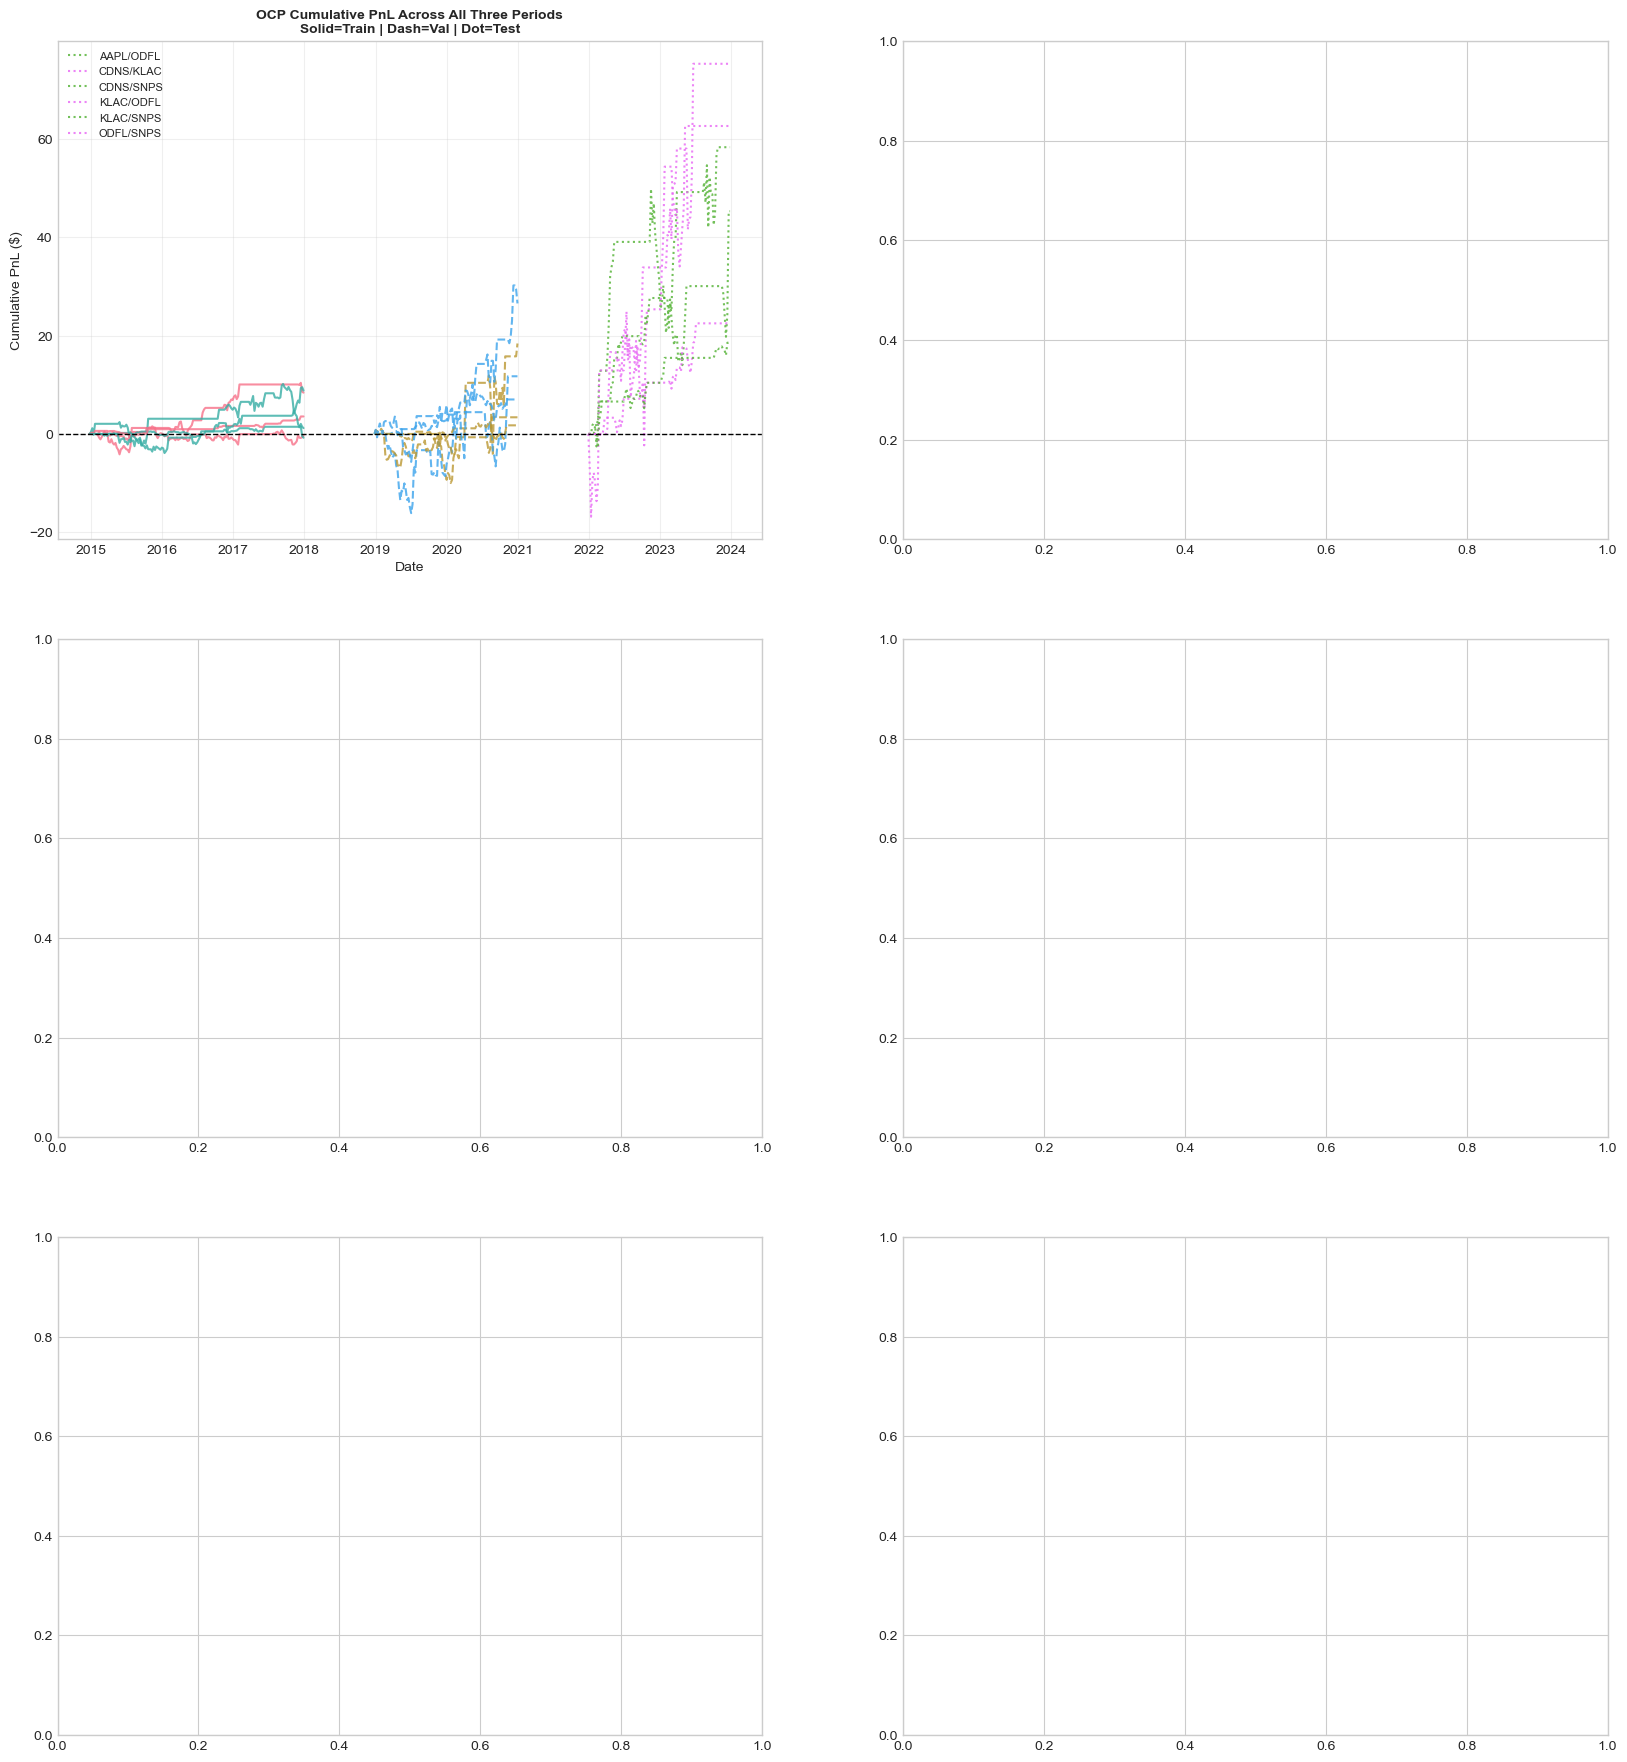

In [22]:
# Visualization: OCP Three-Period Performance Summary

fig, axes = plt.subplots(3,2,figsize=(20,22))

periods       = ['train', 'val', 'test']
period_color  = ['steelblue', 'orange', 'green']
pair_names    = list(ocp_backtest_results.keys())
x             = np.arange(len(pair_names))
width         = 0.25

# Plot 1: Cumulative PnL across all three periods
ax1 = axes[0,0]
for pair_name in ocp_backtest_results.keys():
    for period, linestyle in [('train','-'), ('val','--'), ('test', ':')]:
        results = ocp_backtest_results[pair_name][period]
        label   = pair_name if period == 'test' else None
        ax1.plot(results['cumulative_pnl'],
                 linewidth=1.5, linestyle=linestyle,
                 alpha=0.8, label=label)

ax1.axhline(y=0, color='black', linewidth=1.0, linestyle='--')
ax1.set_title('OCP Cumulative PnL Across All Three Periods\n'
              'Solid=Train | Dash=Val | Dot=Test',
              fontweight='bold', fontsize=10)
ax1.set_ylabel('Cumulative PnL ($)')
ax1.set_xlabel('Date')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)        